simple linear regression
one independet variable(x) and one dependent variable(y)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.datasets as datasets
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, root_mean_squared_error

In [3]:
dataset = pd.read_csv('DataSalary.csv')

In [4]:
dataset.shape # 30 rows and 3 colums

(30, 3)

In [5]:
dataset.head()

,Index,YearsExperience,Salary
0,1,1.1,39343.0
1,2,1.3,46205.0
2,3,1.5,37731.0
3,4,2.0,43525.0
4,5,2.2,39891.0


In [6]:
input = dataset['YearsExperience'] # independent
target = dataset['Salary'] # dependent

In [7]:
X_train, X_test, y_train, y_test = train_test_split(input, target, test_size=0.2, random_state = 42)
model = LinearRegression()
model.fit(X_train.values.reshape(-1, 1), y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
y_pred = model.predict(X_test.values.reshape(-1, 1))

In [9]:
mse = mean_squared_error(y_test,y_pred)
mse1 = np.mean((y_test - y_pred)**2)
mae = mean_absolute_error(y_test, y_pred)
mae1 = np.mean(np.abs(y_test - y_pred))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"mse : {mse} and {mse1}\n mae:{mae} and {mae1}\n rmse: {rmse}\n r2: {r2}")

mse : 49830096.85590839 and 49830096.85590839
 mae:6286.453830757749 and 6286.453830757749
 rmse: 7059.04362190151
 r2: 0.9024461774180497


In [10]:
new_data = 5.5
predicted_salary = model.predict(np.array([[new_data]]))
print(f"Predicted salary for {new_data} years of experience: {predicted_salary[0]}")

Predicted salary for 5.5 years of experience: 77152.56728844717


we need mean_squre error , root mean square error , mean squre error and r^2 for evaluating the model performance

multiple linear regression more than one independent variable and one dependent variable

In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
import seaborn as sns
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [29]:
input = df[['MedInc','HouseAge','AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']] # independent
target = df['target']

In [30]:
print(df.isnull().sum())



MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64


<Axes: xlabel='AveRooms', ylabel='target'>

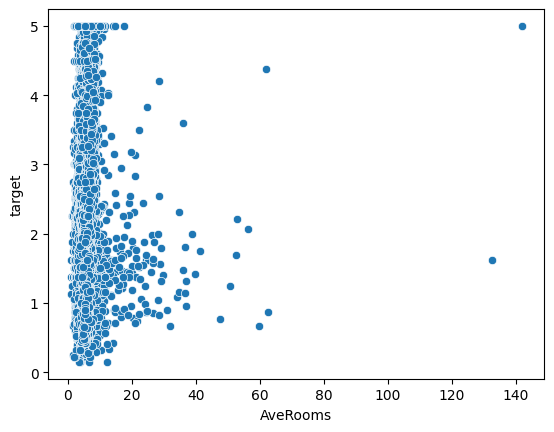

In [31]:
sns.scatterplot(df, x='AveRooms', y='target')

<Axes: xlabel='HouseAge', ylabel='Population'>

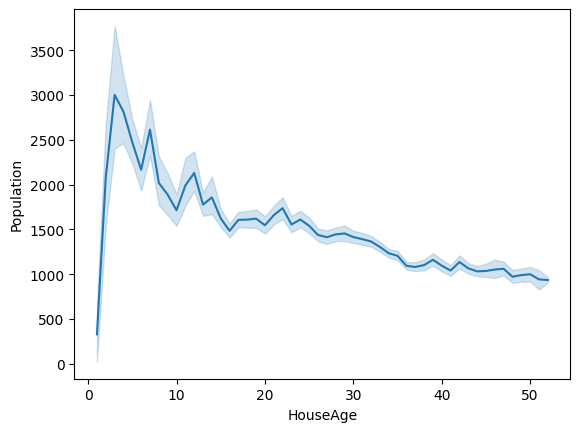

In [32]:
sns.lineplot(df, x='HouseAge', y='Population')

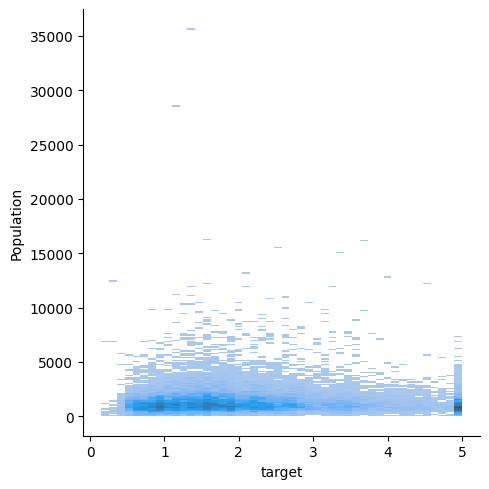

In [38]:
sns.displot(df,x='target', y='Population')

<Axes: >

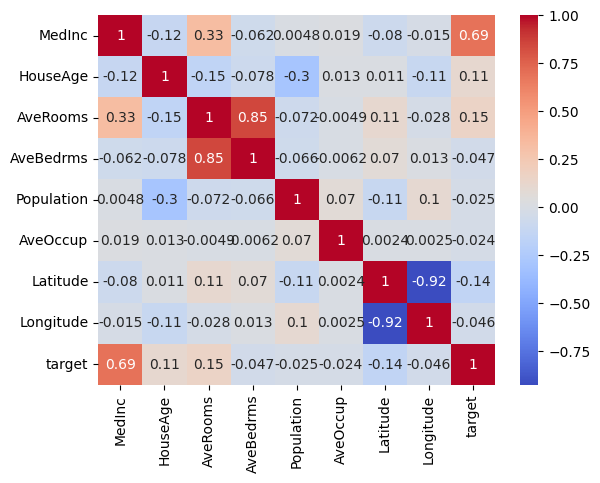

In [40]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

In [ ]:
scaler = StandardScaler()
x_train_scale = scaler.fit_transform(X_train)
x_test_scale = scaler.transform(X_test)

In [41]:
X_train, X_test, y_train, y_test = train_test_split(input, target, test_size=0.2, random_state =42)
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [42]:
y_pred = model.predict(X_test)

In [43]:
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test,y_pred)
print(f"mse : {mse}\n rmse : {rmse} \n r2 : {r2}")

mse : 0.5558915986952435
 rmse : 0.7455813830127758 
 r2 : 0.5757877060324514
